# Notebook 07 — EDA

Weather and Calendar Effects on Cycling Demand

## 0. Imports & Load

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

# Color palette (consistent across all figures)
COLORS = {
    "commuter" : "#2196F3",   # blue
    "mixed"    : "#FFC107",   # amber
    "leisure"  : "#F44336",   # red
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

# Merge site classification (commute_score, site_type) from dedicated parquet
site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[["site ID", "commute_score", "site_type"]]
panel = panel.drop(columns=[c for c in ["commute_score", "site_type"] if c in panel.columns])
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

# Filter out low coverage sites
panel_good = panel[panel["low_coverage"] == False].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"panel_good shape: {panel_good.shape}")
print(f"Columns: {list(panel_good.columns)}")

panel_good shape: (145768, 56)
Columns: ['site ID', 'date', 'aantal', 'morning_peak_count', 'evening_peak_count', 'peak_ratio', 'year', 'month', 'dayofweek', 'is_weekend', 'season', 'low_coverage', 'long', 'lat', 'naam', 'gemeente', 'wegnr', 'district', 'datum_van', 'temp_avg', 'temp_max', 'temp_min', 'precip_total', 'wind_avg', 'wind_max', 'humidity_avg', 'sunshine_min', 'rain_hours', 'precip_morning', 'wind_morning', 'precip_evening', 'wind_evening', 'is_rainy_day', 'is_cold_day', 'is_windy_day', 'is_bad_weather', 'public_holiday_name', 'is_public_holiday', 'school_holiday_name', 'is_school_holiday', 'ku_leuven_period', 'ku_is_teaching', 'ku_is_exam', 'ku_is_exam_prep', 'ku_is_recess', 'is_any_holiday', 'is_regular_day', 'day_type', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'temp_avg_lag2', 'precip_total_lag2', 'wind_avg_lag2', 'commute_score', 'site_type']


## 1. Seasonal Cycling Pattern

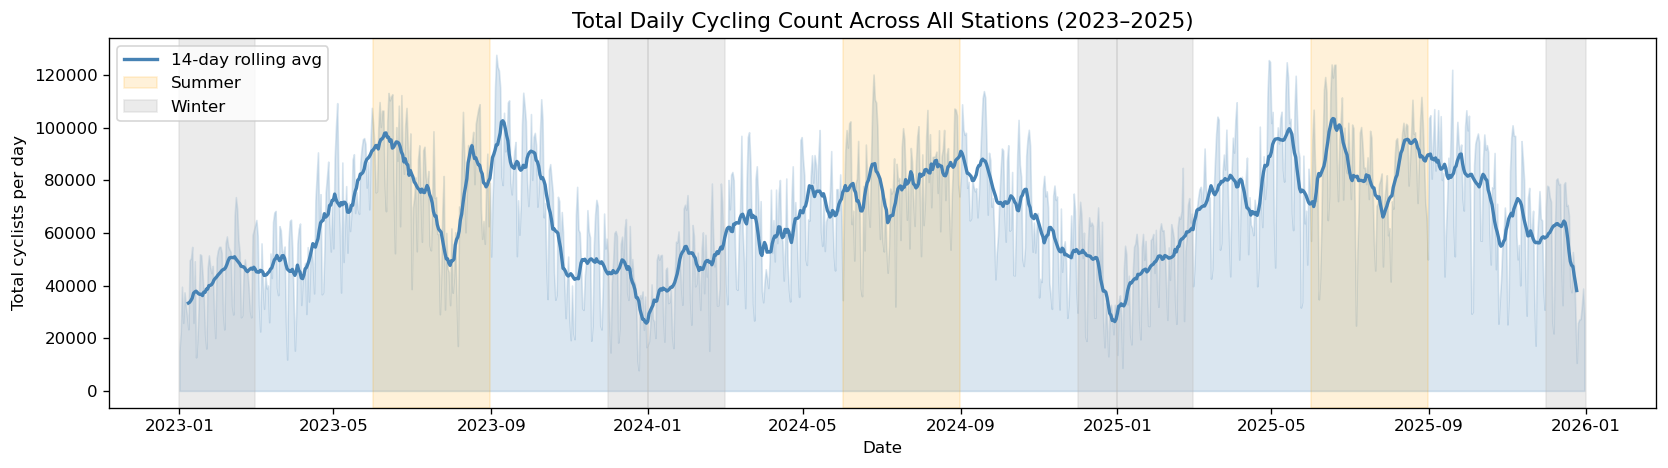

07_seasonal_pattern saved.


In [10]:
daily_total = panel_good.groupby("date")["aantal"].sum().reset_index()
daily_total["date"] = pd.to_datetime(daily_total["date"])

fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(daily_total["date"], daily_total["aantal"],
                alpha=0.2, color="steelblue")

daily_total["rolling"] = daily_total["aantal"].rolling(14, center=True).mean()
ax.plot(daily_total["date"], daily_total["rolling"],
        color="steelblue", linewidth=2, label="14-day rolling avg")

for year in [2023, 2024, 2025]:
    ax.axvspan(pd.Timestamp(f"{year}-06-01"), pd.Timestamp(f"{year}-08-31"),
               alpha=0.15, color="orange", label="Summer" if year == 2023 else "")
    ax.axvspan(pd.Timestamp(f"{year}-01-01"), pd.Timestamp(f"{year}-03-01"),
               alpha=0.30, color="silver", label="Winter" if year == 2023 else "")
    ax.axvspan(pd.Timestamp(f"{year}-12-01"), pd.Timestamp(f"{year+1}-01-01"),
               alpha=0.30, color="silver")

ax.set_title("Total Daily Cycling Count Across All Stations (2023–2025)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Total cyclists per day")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "07_seasonal_pattern.png", dpi=150)
plt.show()
print("07_seasonal_pattern saved.")

## 2. Weather Variable Distributions

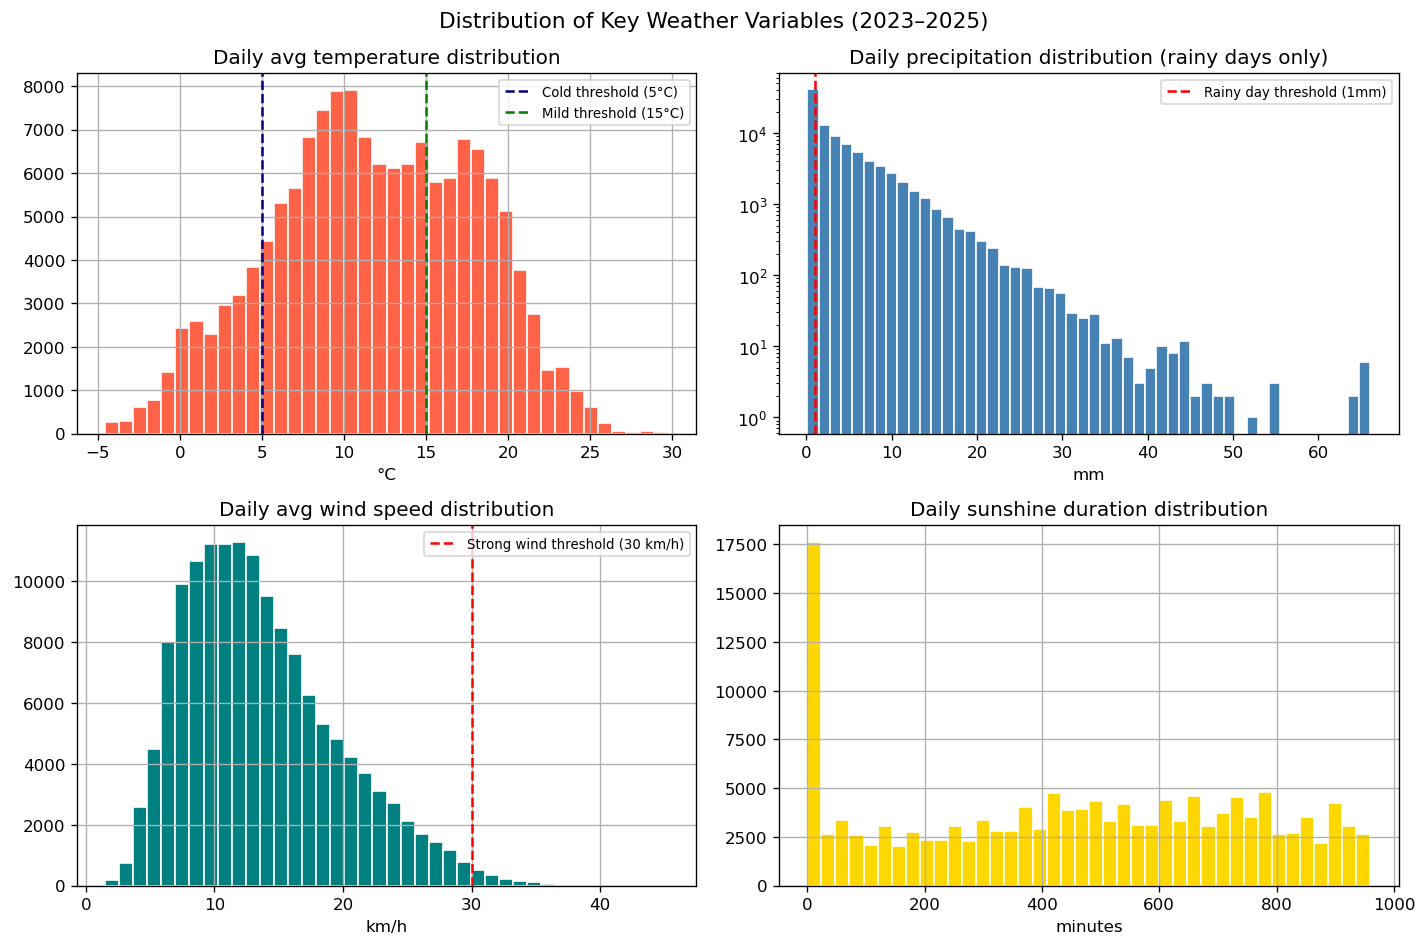

07_weather_distributions.png saved.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
panel_good["temp_avg"].hist(bins=40, ax=ax, color="tomato", edgecolor="white")
ax.axvline(5,  color="navy",  linestyle="--", label="Cold threshold (5\u00b0C)")
ax.axvline(15, color="green", linestyle="--", label="Mild threshold (15\u00b0C)")
ax.set_title("Daily avg temperature distribution")
ax.set_xlabel("\u00b0C")
ax.legend(fontsize=8)

ax = axes[0, 1]
precip_nonzero = panel_good[panel_good["precip_total"] > 0]["precip_total"]
ax.hist(precip_nonzero, bins=50, color="steelblue", edgecolor="white", log=True)
ax.axvline(1.0, color="red", linestyle="--", label="Rainy day threshold (1mm)")
ax.set_title("Daily precipitation distribution (rainy days only)")
ax.set_xlabel("mm")
ax.legend(fontsize=8)

ax = axes[1, 0]
panel_good["wind_avg"].hist(bins=40, ax=ax, color="teal", edgecolor="white")
ax.axvline(30, color="red", linestyle="--", label="Strong wind threshold (30 km/h)")
ax.set_title("Daily avg wind speed distribution")
ax.set_xlabel("km/h")
ax.legend(fontsize=8)

ax = axes[1, 1]
panel_good["sunshine_min"].hist(bins=40, ax=ax, color="gold", edgecolor="white")
ax.set_title("Daily sunshine duration distribution")
ax.set_xlabel("minutes")

fig.suptitle("Distribution of Key Weather Variables (2023\u20132025)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "07_weather_distributions.png", dpi=150)
plt.show()
print("07_weather_distributions.png saved.")

## 3. Weather vs Cycling

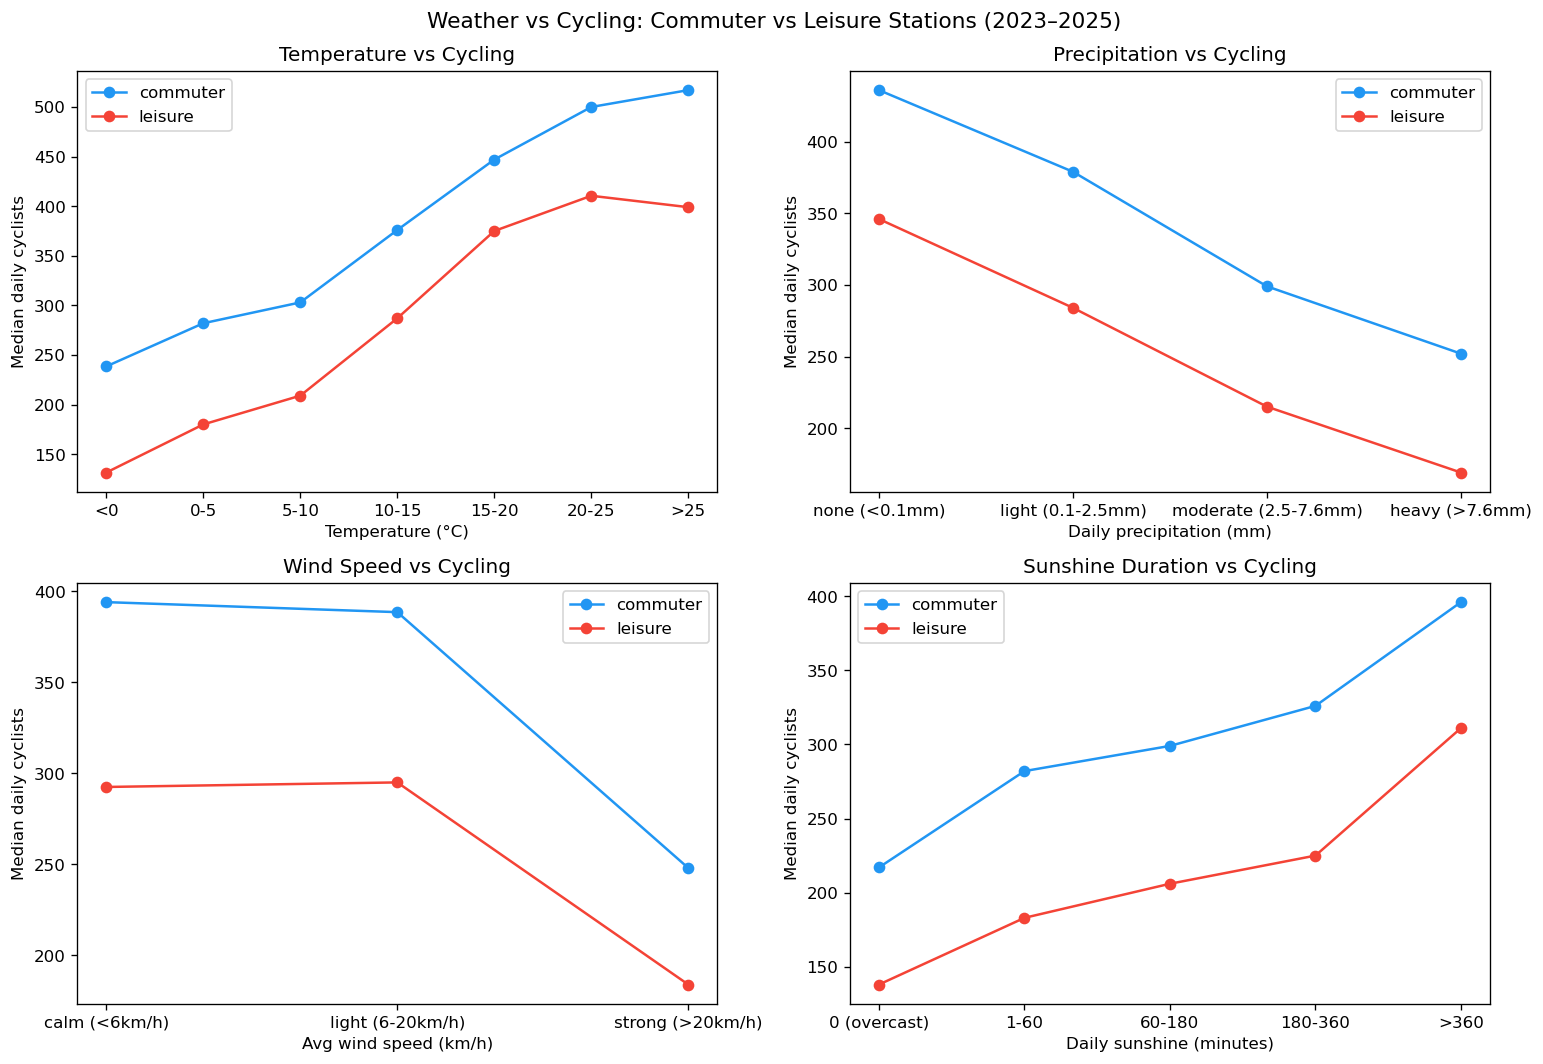

07_weather_vs_cycling saved.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for site_type, color in [("commuter", COLORS["commuter"]),
                          ("leisure",  COLORS["leisure"])]:
    sub = panel_good[panel_good["site_type"] == site_type].copy()

    sub["temp_bin"] = pd.cut(sub["temp_avg"],
        bins=[-5, 0, 5, 10, 15, 20, 25, 35],
        labels=["<0", "0-5", "5-10", "10-15", "15-20", "20-25", ">25"])
    temp_med = sub.groupby("temp_bin", observed=True)["aantal"].median()
    axes[0, 0].plot(temp_med.index.astype(str), temp_med.values,
                    marker="o", label=site_type, color=color)

    sub["precip_bin"] = pd.cut(sub["precip_total"],
        bins=[-0.01, 0.1, 2.5, 7.6, 100],
        labels=["none (<0.1mm)", "light (0.1-2.5mm)", "moderate (2.5-7.6mm)", "heavy (>7.6mm)"])
    precip_med = sub.groupby("precip_bin", observed=True)["aantal"].median()
    axes[0, 1].plot(precip_med.index.astype(str), precip_med.values,
                    marker="o", label=site_type, color=color)

    sub["wind_bin"] = pd.cut(sub["wind_avg"],
        bins=[-0.01, 6, 20, 200],
        labels=["calm (<6km/h)", "light (6-20km/h)", "strong (>20km/h)"])
    wind_med = sub.groupby("wind_bin", observed=True)["aantal"].median()
    axes[1, 0].plot(wind_med.index.astype(str), wind_med.values,
                    marker="o", label=site_type, color=color)

    sub["sun_bin"] = pd.cut(sub["sunshine_min"],
        bins=[-1, 0, 60, 180, 360, 800],
        labels=["0 (overcast)", "1-60", "60-180", "180-360", ">360"])
    sun_med = sub.groupby("sun_bin", observed=True)["aantal"].median()
    axes[1, 1].plot(sun_med.index.astype(str), sun_med.values,
                    marker="o", label=site_type, color=color)

for ax, title, xlabel in zip(
    axes.flat,
    ["Temperature vs Cycling", "Precipitation vs Cycling",
     "Wind Speed vs Cycling", "Sunshine Duration vs Cycling"],
    ["Temperature (\u00b0C)", "Daily precipitation (mm)",
     "Avg wind speed (km/h)", "Daily sunshine (minutes)"],
):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Median daily cyclists")
    ax.legend()

fig.suptitle("Weather vs Cycling: Commuter vs Leisure Stations (2023\u20132025)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "07_weather_vs_cycling.png", dpi=150)
plt.show()
print("07_weather_vs_cycling saved.")

## 4. Bad Weather Resilience by Site Type

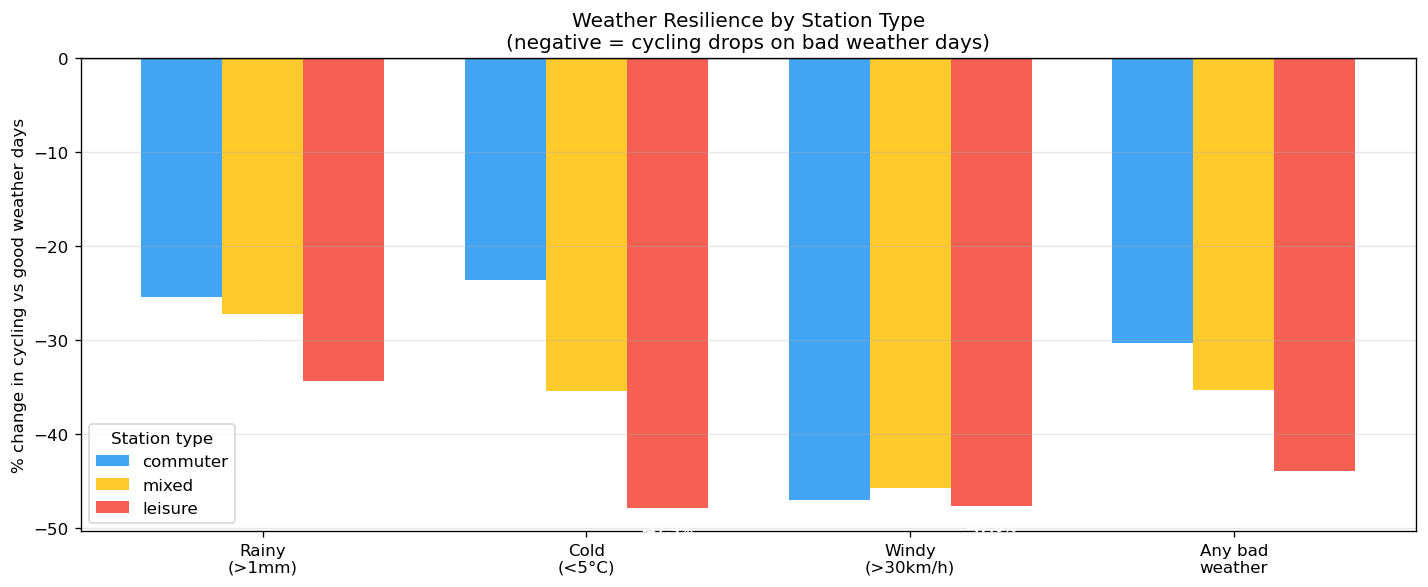

07_weather_resilience_by_type saved.


In [13]:
bad_weather_types = {
    "Rainy\n(>1mm)"    : "is_rainy_day",
    "Cold\n(<5\u00b0C)" : "is_cold_day",
    "Windy\n(>30km/h)" : "is_windy_day",
    "Any bad\nweather"  : "is_bad_weather",
}

fig, ax = plt.subplots(figsize=(12, 5))

x       = np.arange(len(bad_weather_types))
width   = 0.25
offsets = [-width, 0, width]

for i, site_type in enumerate(["commuter", "mixed", "leisure"]):
    sub = panel_good[panel_good["site_type"] == site_type]
    drops = []
    for col in bad_weather_types.values():
        good_avg = sub[sub[col] == False]["aantal"].mean()
        bad_avg  = sub[sub[col] == True]["aantal"].mean()
        drops.append((bad_avg - good_avg) / good_avg * 100)
    bars = ax.bar(x + offsets[i], drops, width,
                  label=site_type, color=COLORS[site_type], alpha=0.85)
    for bar, val in zip(bars, drops):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() - 1.5,
                f"{val:.1f}%", ha="center", va="top",
                fontsize=8, color="white", fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(bad_weather_types.keys())
ax.set_ylabel("% change in cycling vs good weather days")
ax.set_title("Weather Resilience by Station Type\n"
             "(negative = cycling drops on bad weather days)")
ax.legend(title="Station type")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "07_weather_resilience_by_type.png", dpi=150)
plt.show()
print("07_weather_resilience_by_type saved.")


Strong wind days (> 30 km/h, Beaufort force 5) accounted for only 1.1% of station-days in the study period, reflecting Belgium's generally moderate wind climate.

## 5. Calendar Effects

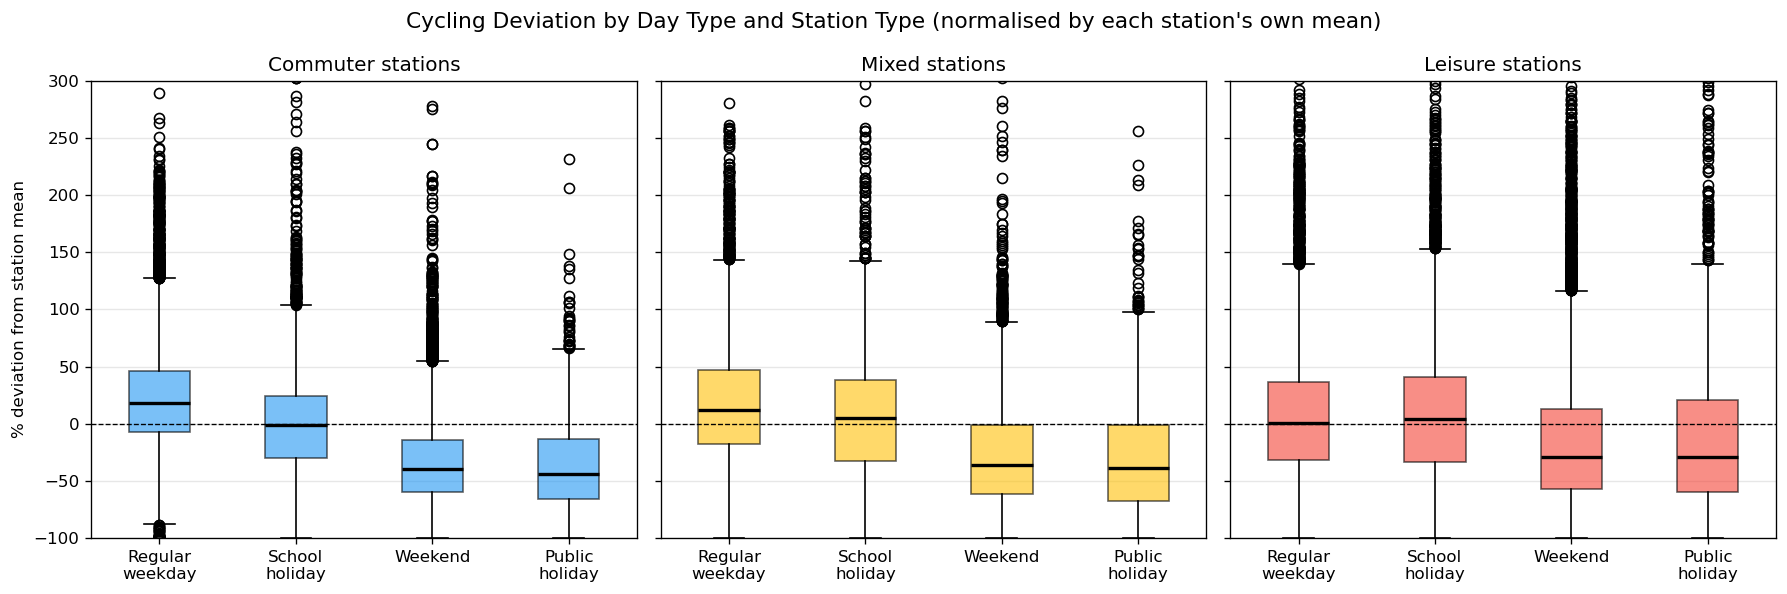

07_calendar_effects saved.


In [14]:
# Normalise by each station's own mean to remove between-station volume differences
station_mean = panel_good.groupby("site ID")["aantal"].mean().rename("station_mean")
panel_norm = panel_good.join(station_mean, on="site ID")
panel_norm["pct_dev"] = (panel_norm["aantal"] - panel_norm["station_mean"]) / panel_norm["station_mean"] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

day_order  = ["regular_weekday", "school_holiday", "weekend", "public_holiday"]
day_labels = ["Regular\nweekday", "School\nholiday", "Weekend", "Public\nholiday"]

for ax, site_type in zip(axes, ["commuter", "mixed", "leisure"]):
    sub = panel_norm[panel_norm["site_type"] == site_type]
    data_by_type = [sub[sub["day_type"] == dt]["pct_dev"].dropna().values
                    for dt in day_order]
    bp = ax.boxplot(data_by_type, tick_labels=day_labels,
                    patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(COLORS[site_type])
        patch.set_alpha(0.6)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylim(-100, 300)
    ax.set_title(f"{site_type.capitalize()} stations")
    ax.set_ylabel("% deviation from station mean" if site_type == "commuter" else "")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Cycling Deviation by Day Type and Station Type (normalised by each station's own mean)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "07_calendar_effects.png", dpi=150)
plt.show()
print("07_calendar_effects saved.")

## 6. Leuven Totem Analysis

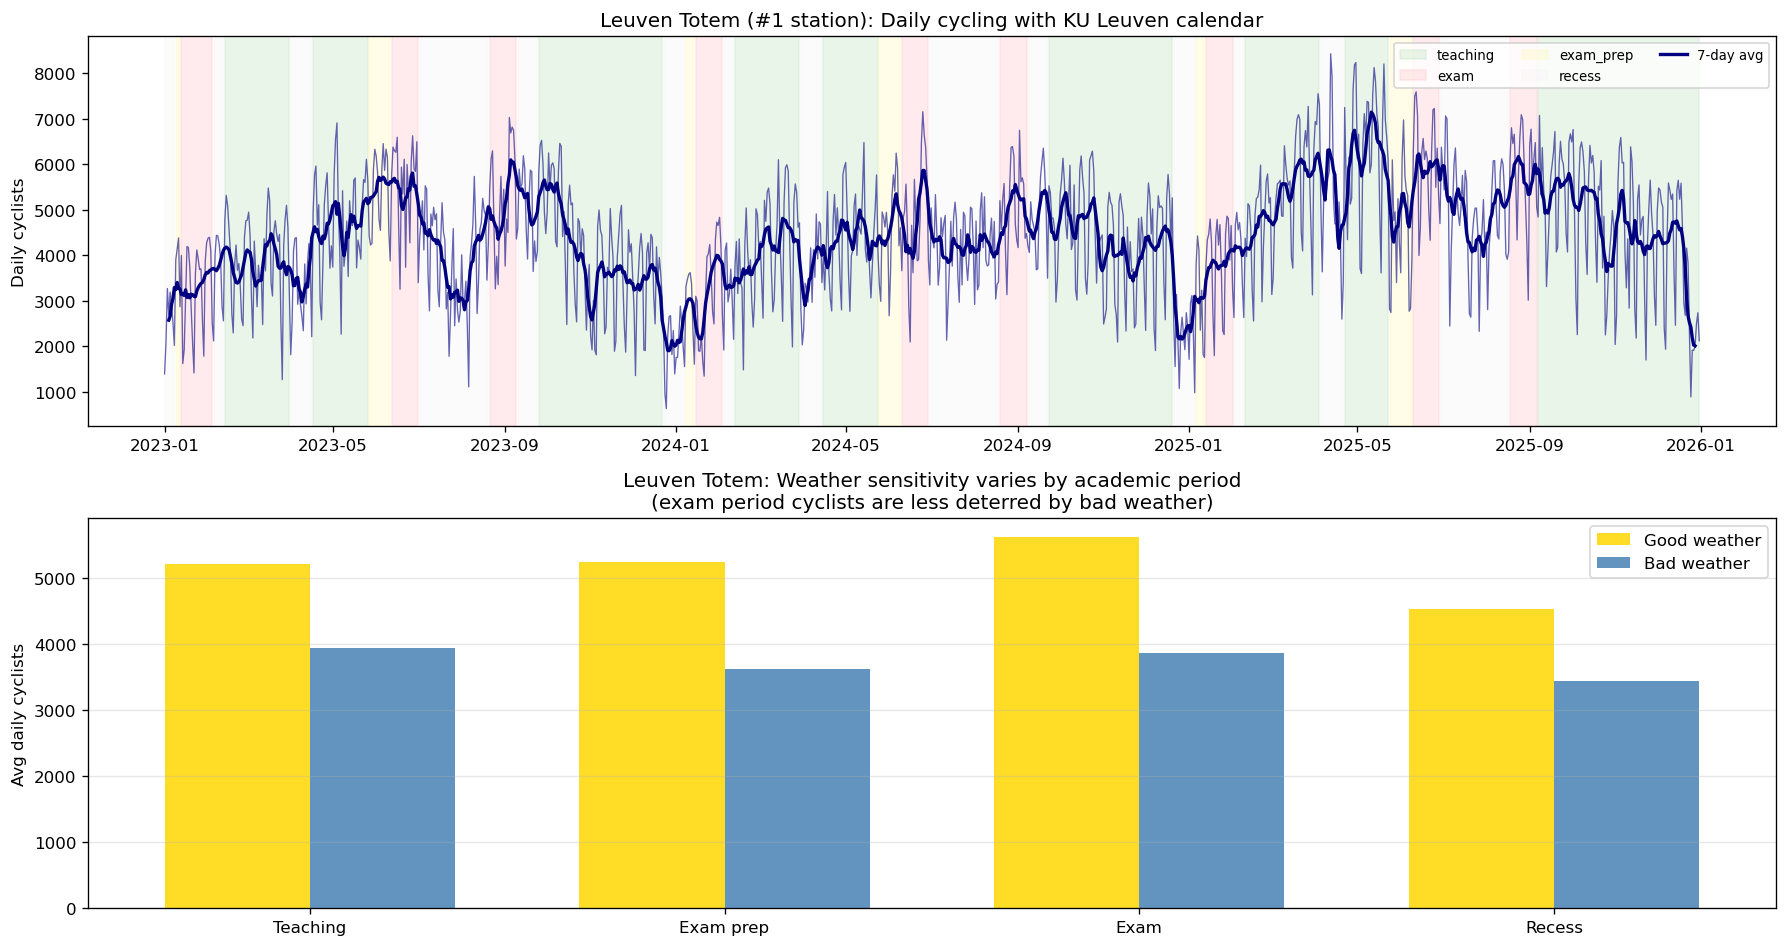

07_leuven_totem_deep_dive saved.


In [15]:
leuven = panel_good[panel_good["site ID"] == 107].copy()
leuven["date"] = pd.to_datetime(leuven["date"])

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

ku_colors = {
    "teaching"  : "#C8E6C9",
    "exam"      : "#FFCDD2",
    "exam_prep" : "#FFF9C4",
    "recess"    : "#F5F5F5",
}

# Panel A: full time series with KU Leuven period shading
ax = axes[0]
for period, color in ku_colors.items():
    mask = leuven["ku_leuven_period"] == period
    if not mask.any():
        continue
    leuven_sorted = leuven[mask].sort_values("date")
    start = leuven_sorted["date"].iloc[0]
    prev  = start
    for d in leuven_sorted["date"].iloc[1:]:
        if (d - prev).days > 1:
            ax.axvspan(start, prev, alpha=0.4, color=color)
            start = d
        prev = d
    ax.axvspan(start, prev, alpha=0.4, color=color, label=period)

ax.plot(leuven["date"], leuven["aantal"],
        color="navy", linewidth=0.8, alpha=0.6)
rolling = leuven.set_index("date")["aantal"].rolling(7, center=True).mean()
ax.plot(rolling.index, rolling.values, color="navy", linewidth=2, label="7-day avg")
ax.set_title("Leuven Totem (#1 station): Daily cycling with KU Leuven calendar")
ax.set_ylabel("Daily cyclists")
ax.legend(loc="upper right", ncol=3, fontsize=8)

# Panel B: avg cycling by KU Leuven period x weather
ax    = axes[1]
ku_order  = ["teaching", "exam_prep", "exam", "recess"]
good_avgs = [leuven[(leuven["ku_leuven_period"] == p) & (leuven["is_bad_weather"] == False)]["aantal"].mean()
             for p in ku_order]
bad_avgs  = [leuven[(leuven["ku_leuven_period"] == p) & (leuven["is_bad_weather"] == True)]["aantal"].mean()
             for p in ku_order]

x = np.arange(len(ku_order))
w = 0.35
ax.bar(x - w/2, good_avgs, w, label="Good weather", color="gold",      alpha=0.85)
ax.bar(x + w/2, bad_avgs,  w, label="Bad weather",  color="steelblue", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["Teaching", "Exam prep", "Exam", "Recess"])
ax.set_ylabel("Avg daily cyclists")
ax.set_title("Leuven Totem: Weather sensitivity varies by academic period\n"
             "(exam period cyclists are less deterred by bad weather)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGS / "07_leuven_totem_deep_dive.png", dpi=150)
plt.show()
print("07_leuven_totem_deep_dive saved.")

However, Leuven Totem is not the closest station to the school. Maybe change to other station in the future work.

## 7. EDA Summary Statistics

In [16]:
summer = panel_good[panel_good["season"] == "summer"]["aantal"].mean()
winter = panel_good[panel_good["season"] == "winter"]["aantal"].mean()
print(f"Seasonal effect:")
print(f"  Summer avg: {summer:.0f} cyclists/day")
print(f"  Winter avg: {winter:.0f} cyclists/day")
print(f"  Ratio: {summer/winter:.2f}x")

dry   = panel_good[panel_good["is_rainy_day"] == False]["aantal"].mean()
rainy = panel_good[panel_good["is_rainy_day"] == True]["aantal"].mean()
print(f"\nRain effect (all stations):")
print(f"  Dry day avg:   {dry:.0f}")
print(f"  Rainy day avg: {rainy:.0f}")
print(f"  Drop: {(rainy - dry) / dry * 100:.1f}%")

mild = panel_good[panel_good["temp_avg"] >= 10]["aantal"].mean()
cold = panel_good[panel_good["temp_avg"] <  5]["aantal"].mean()
print(f"\nCold effect:")
print(f"  Mild (>=10\u00b0C) avg: {mild:.0f}")
print(f"  Cold (<5\u00b0C) avg:   {cold:.0f}")
print(f"  Drop: {(cold - mild) / mild * 100:.1f}%")

print(f"\nDay type averages:")
for dt in ["regular_weekday", "school_holiday", "weekend", "public_holiday"]:
    avg = panel_good[panel_good["day_type"] == dt]["aantal"].mean()
    print(f"  {dt:20s}: {avg:.0f} avg cyclists")

print(f"\nRain sensitivity by site type:")
for st in ["commuter", "leisure"]:
    sub  = panel_good[panel_good["site_type"] == st]
    dry  = sub[sub["is_rainy_day"] == False]["aantal"].mean()
    rain = sub[sub["is_rainy_day"] == True]["aantal"].mean()
    print(f"  {st} rain drop: {(rain - dry) / dry * 100:.1f}%")

print(f"\nLeuven Totem bad weather drop by academic period:")
leuven = panel_good[panel_good["site ID"] == 107]
for period in ["teaching", "exam", "recess"]:
    sub = leuven[leuven["ku_leuven_period"] == period]
    if sub.empty:
        continue
    dry = sub[sub["is_bad_weather"] == False]["aantal"].mean()
    bad = sub[sub["is_bad_weather"] == True]["aantal"].mean()
    print(f"  {period:10s}: {(bad - dry) / dry * 100:.1f}%")


Seasonal effect:
  Summer avg: 610 cyclists/day
  Winter avg: 347 cyclists/day
  Ratio: 1.76x

Rain effect (all stations):
  Dry day avg:   570
  Rainy day avg: 407
  Drop: -28.6%

Cold effect:
  Mild (>=10°C) avg: 581
  Cold (<5°C) avg:   356
  Drop: -38.7%

Day type averages:
  regular_weekday     : 578 avg cyclists
  school_holiday      : 520 avg cyclists
  weekend             : 375 avg cyclists
  public_holiday      : 380 avg cyclists

Rain sensitivity by site type:
  commuter rain drop: -25.5%
  leisure rain drop: -34.3%

Leuven Totem bad weather drop by academic period:
  teaching  : -24.4%
  exam      : -31.2%
  recess    : -24.1%
